# Class Work 2: Manifold Learning

Welcome to the second tutorial. In this notebook, we move from linear hyperplanes to curved hypersurfaces (manifolds). We will explore why linear methods fail on manifolds and learn how to use t-SNE and UMAP to flatten these structures while preserving local neighborhoods.

Look for `___` or `TODO` to complete the code exercises.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_swiss_roll
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

try:
    import umap
except ImportError:
    print('Please install umap-learn: !pip install umap-learn')


## 1. The Swiss Roll: A Classic Manifold
The Swiss Roll is a 2D sheet rolled up into 3D space. Points that are far away on the sheet might appear close in 3D Euclidean space if they are on adjacent folds.

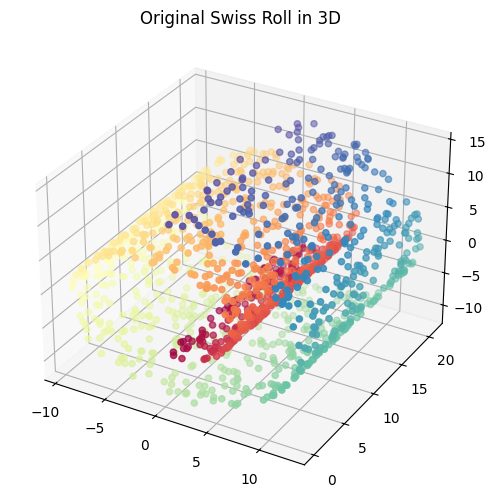

In [8]:
# Generate the Swiss Roll dataset
X_swiss, color = make_swiss_roll(n_samples=1500, random_state=42)

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_swiss[:, 0], X_swiss[:, 1], X_swiss[:, 2], c=color, cmap='Spectral')
ax.set_title('Original Swiss Roll in 3D')
plt.show()

## 2. Failure of PCA on Manifolds
If we apply PCA, it will try to find a flat straight plane. This causes points from different folds to be squashed together.

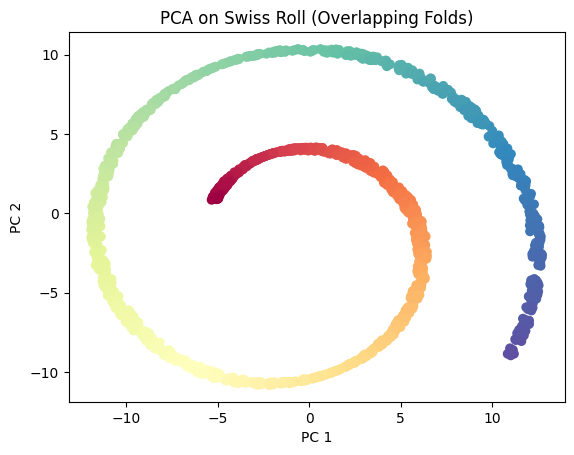

In [10]:
# Initialize PCA for 2 components and transform X_swiss
pca = PCA(n_components=2) # Solution
X_pca = pca.fit_transform(X_swiss) # Solution

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=color, cmap='Spectral')
plt.title('PCA on Swiss Roll (Overlapping Folds)')
plt.xlabel('PC 1')
plt.ylabel('PC 2')
plt.show()

## 3. t-Distributed Stochastic Neighbor Embedding (t-SNE)
t-SNE models geometric distances as probability distributions. It uses a Gaussian distribution in the high-dimensional space and a Student's t-distribution (with heavy tails) in the low-dimensional space to prevent crowding.

The `perplexity` parameter determines the effective number of local neighbors.

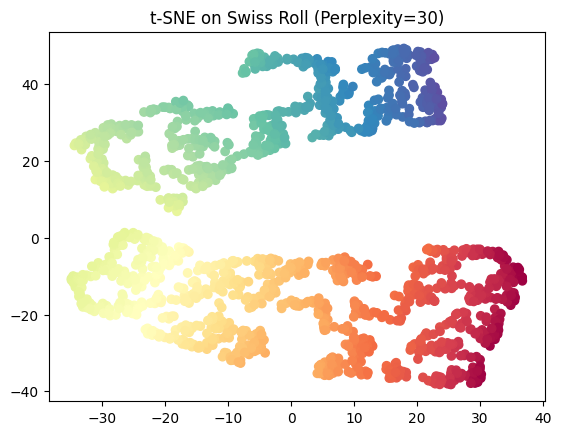

In [11]:
# Initialize TSNE with 2 components, perplexity=30, and random_state=42
# tsne = TSNE(n_components=___, perplexity=___, random_state=___)
tsne = TSNE(n_components=2, perplexity=30, random_state=42) # Solution

# Transform the data. Note: t-SNE does not have a transform method for new data, so we use fit_transform.
# X_tsne = tsne.fit_transform(___)
X_tsne = tsne.fit_transform(X_swiss) # Solution

plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=color, cmap='Spectral')
plt.title('t-SNE on Swiss Roll (Perplexity=30)')
plt.show()

## 4. Uniform Manifold Approximation and Projection (UMAP)
UMAP preserves global structure better than t-SNE by using cross-entropy as its loss function. The term `(1 - P)` penalizes placing distant points too close together. UMAP also provides a transform function, allowing it to be part of a production pipeline.

Key parameters:
- `n_neighbors`: Balances local vs global structure.
- `min_dist`: Controls how tightly points are packed.

C:\Users\User\AppData\Roaming\Python\Python313\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


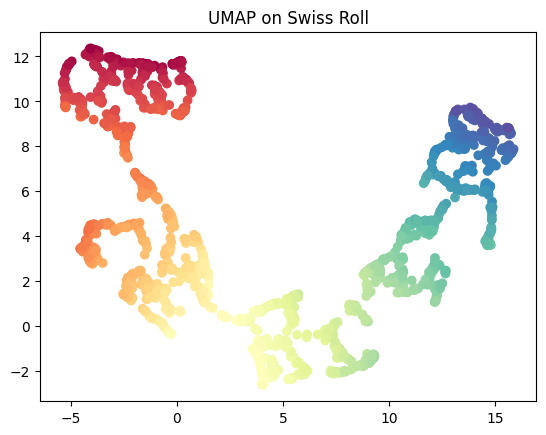

In [12]:
# Initialize UMAP with n_neighbors=15, min_dist=0.1, and random_state=42

if 'umap' in globals():
    umap_model = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42) # Solution
    X_umap = umap_model.fit_transform(X_swiss) # Solution

    plt.scatter(X_umap[:, 0], X_umap[:, 1], c=color, cmap='Spectral')
    plt.title('UMAP on Swiss Roll')
    plt.show()
else:
    print('UMAP not installed. Skipping plot.')

## Conclusion
Use PCA for fast, interpretable linear projection.
Use t-SNE for beautiful local visualizations.
Use UMAP when you need speed, global structure preservation, or a transform function for new data.